# Comparing LFP Theta power for correct and incorrect trials -- noise added

working with the 4Hz model data, generated for delay=400, with gaussian noise std=1

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import lfp_utils as lu
from bootstrap_method import *
import population_utils as pu



2025-10-08 17:11:43.715002: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 17:11:43.726617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-08 17:11:43.739323: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-08 17:11:43.742938: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-08 17:11:43.753733: I tensorflow/core/platform/cpu_feature_guar

In [2]:
condn_phrase = 'delay400noisegaussian1phaseshift1'
condn_num = ''

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
# theta8_dirs = [m for m in model_dirs if '8.0' in m] # 8Hz models only

print(f'Number of 4Hz models: {len(theta4_dirs)}')

perfs = []
for model_name in theta4_dirs:
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    perfs.append(np.mean(trial_perfs))
    print(f'Model {model_name}, performance: {np.mean(trial_perfs):.2f}')

Number of 4Hz models: 22
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, performance: 0.61
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, performance: 0.94
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, performance: 0.61
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, performance: 0.58
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726, performance: 0.50
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802, performance: 0.56
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736, performance: 0.57
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559, performance: 0.84
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527, performance: 0.57
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653, performance: 0.51
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450, performance: 0.54
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025

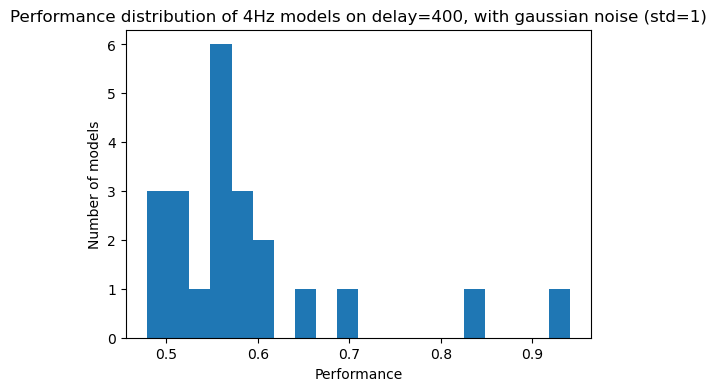

In [4]:
plt.figure(figsize=(6,4))
plt.hist(perfs, bins=20)
plt.xlabel('Performance')
plt.ylabel('Number of models')
plt.title('Performance distribution of 4Hz models on delay=400, with gaussian noise (std=1)')
plt.show()

### apply to multiple models

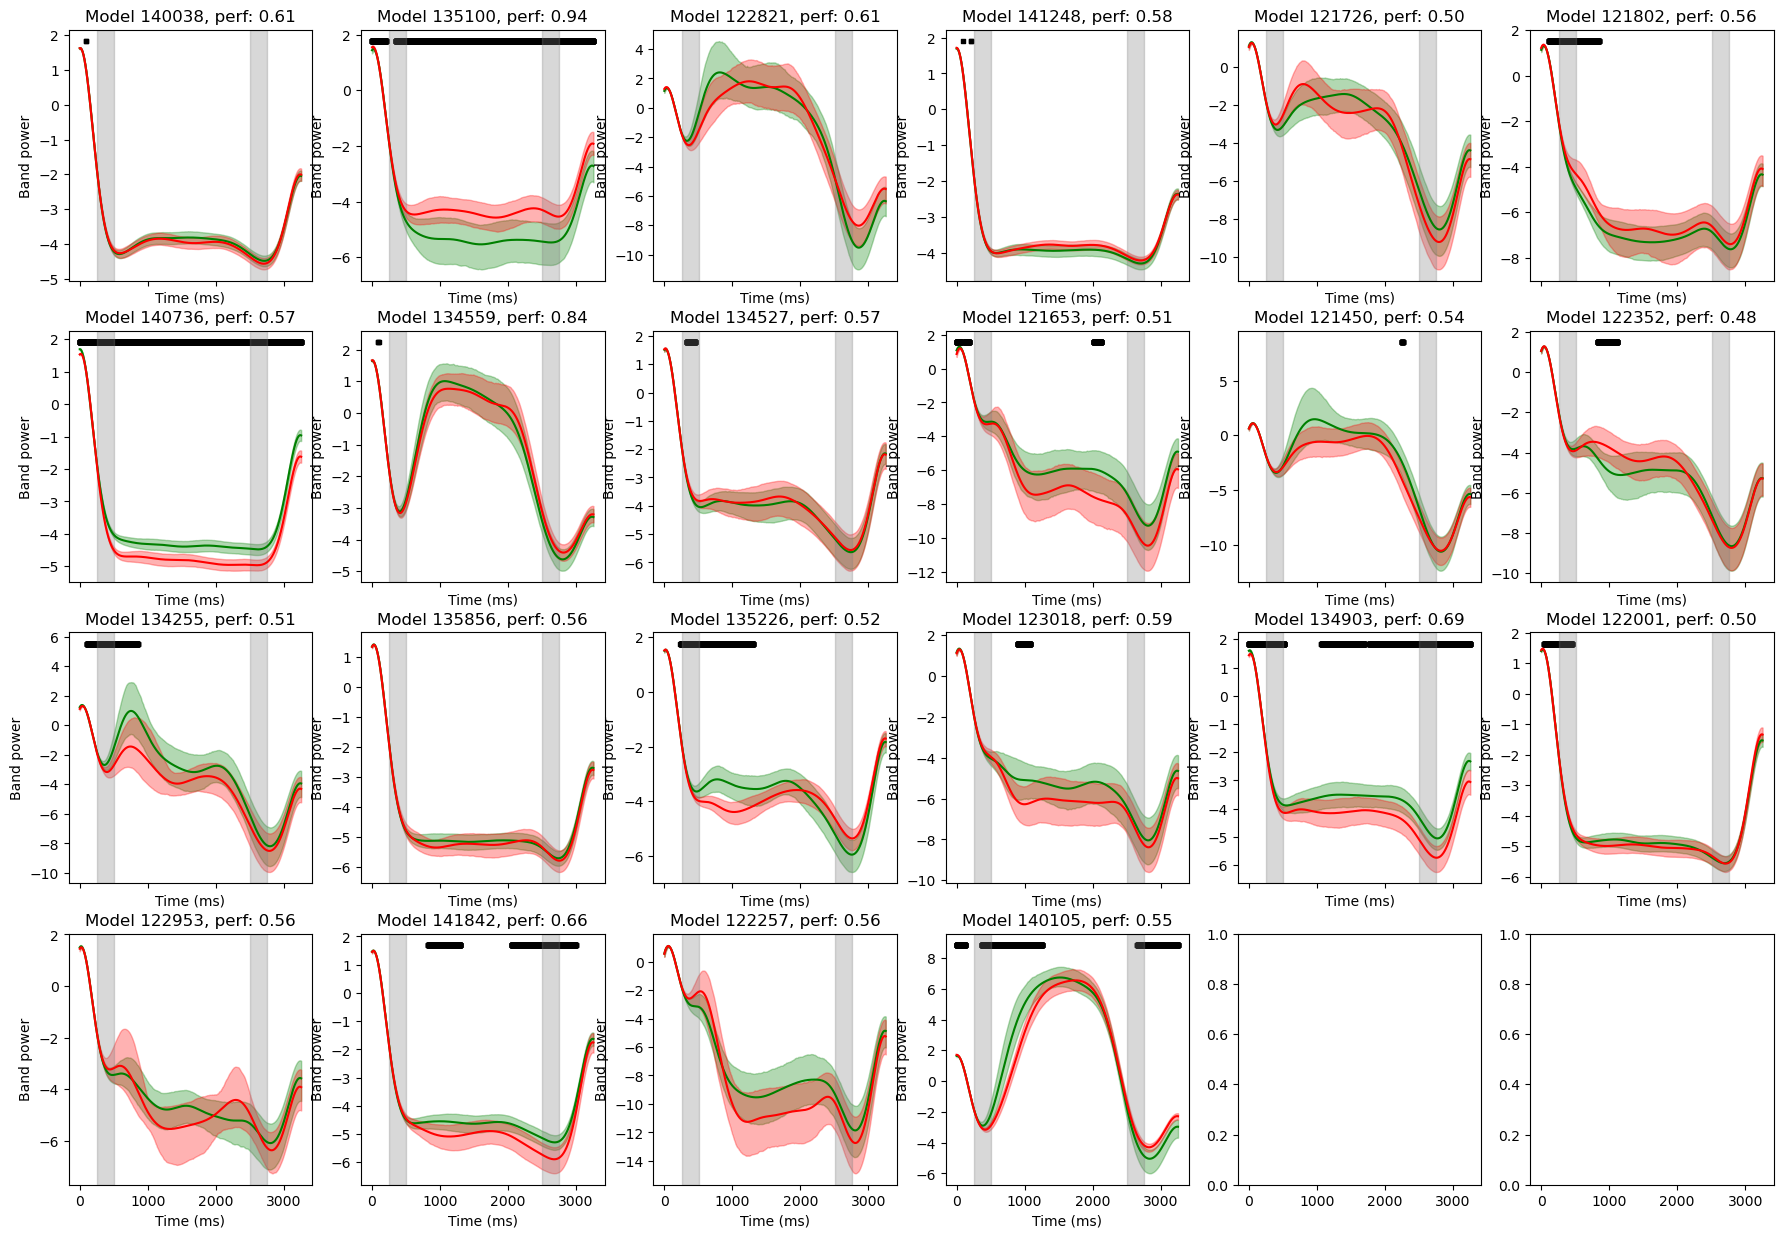

In [5]:
importlib.reload(lu)

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

corrs = []
incorrs = []
corr_CIs = []
incorr_CIs = []
ps = []

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(theta4_dirs):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    # split by correct vs incorrect trials
    bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
    bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
    
    if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
        print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
        continue
    
    # plot with bootstrap CIs
    _, corr, incorr, corr_CI, incorr_CI, p = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                ax = axs[i_model], all_models_dir=all_models_dir)
    
    corrs.append(corr)
    incorrs.append(incorr)
    corr_CIs.append(corr_CI)
    incorr_CIs.append(incorr_CI)
    ps.append(p)
    

### split by stim1 identity and then corr/incorr

Text(0.5, 0.98, 'Stimulus 1 = +1')

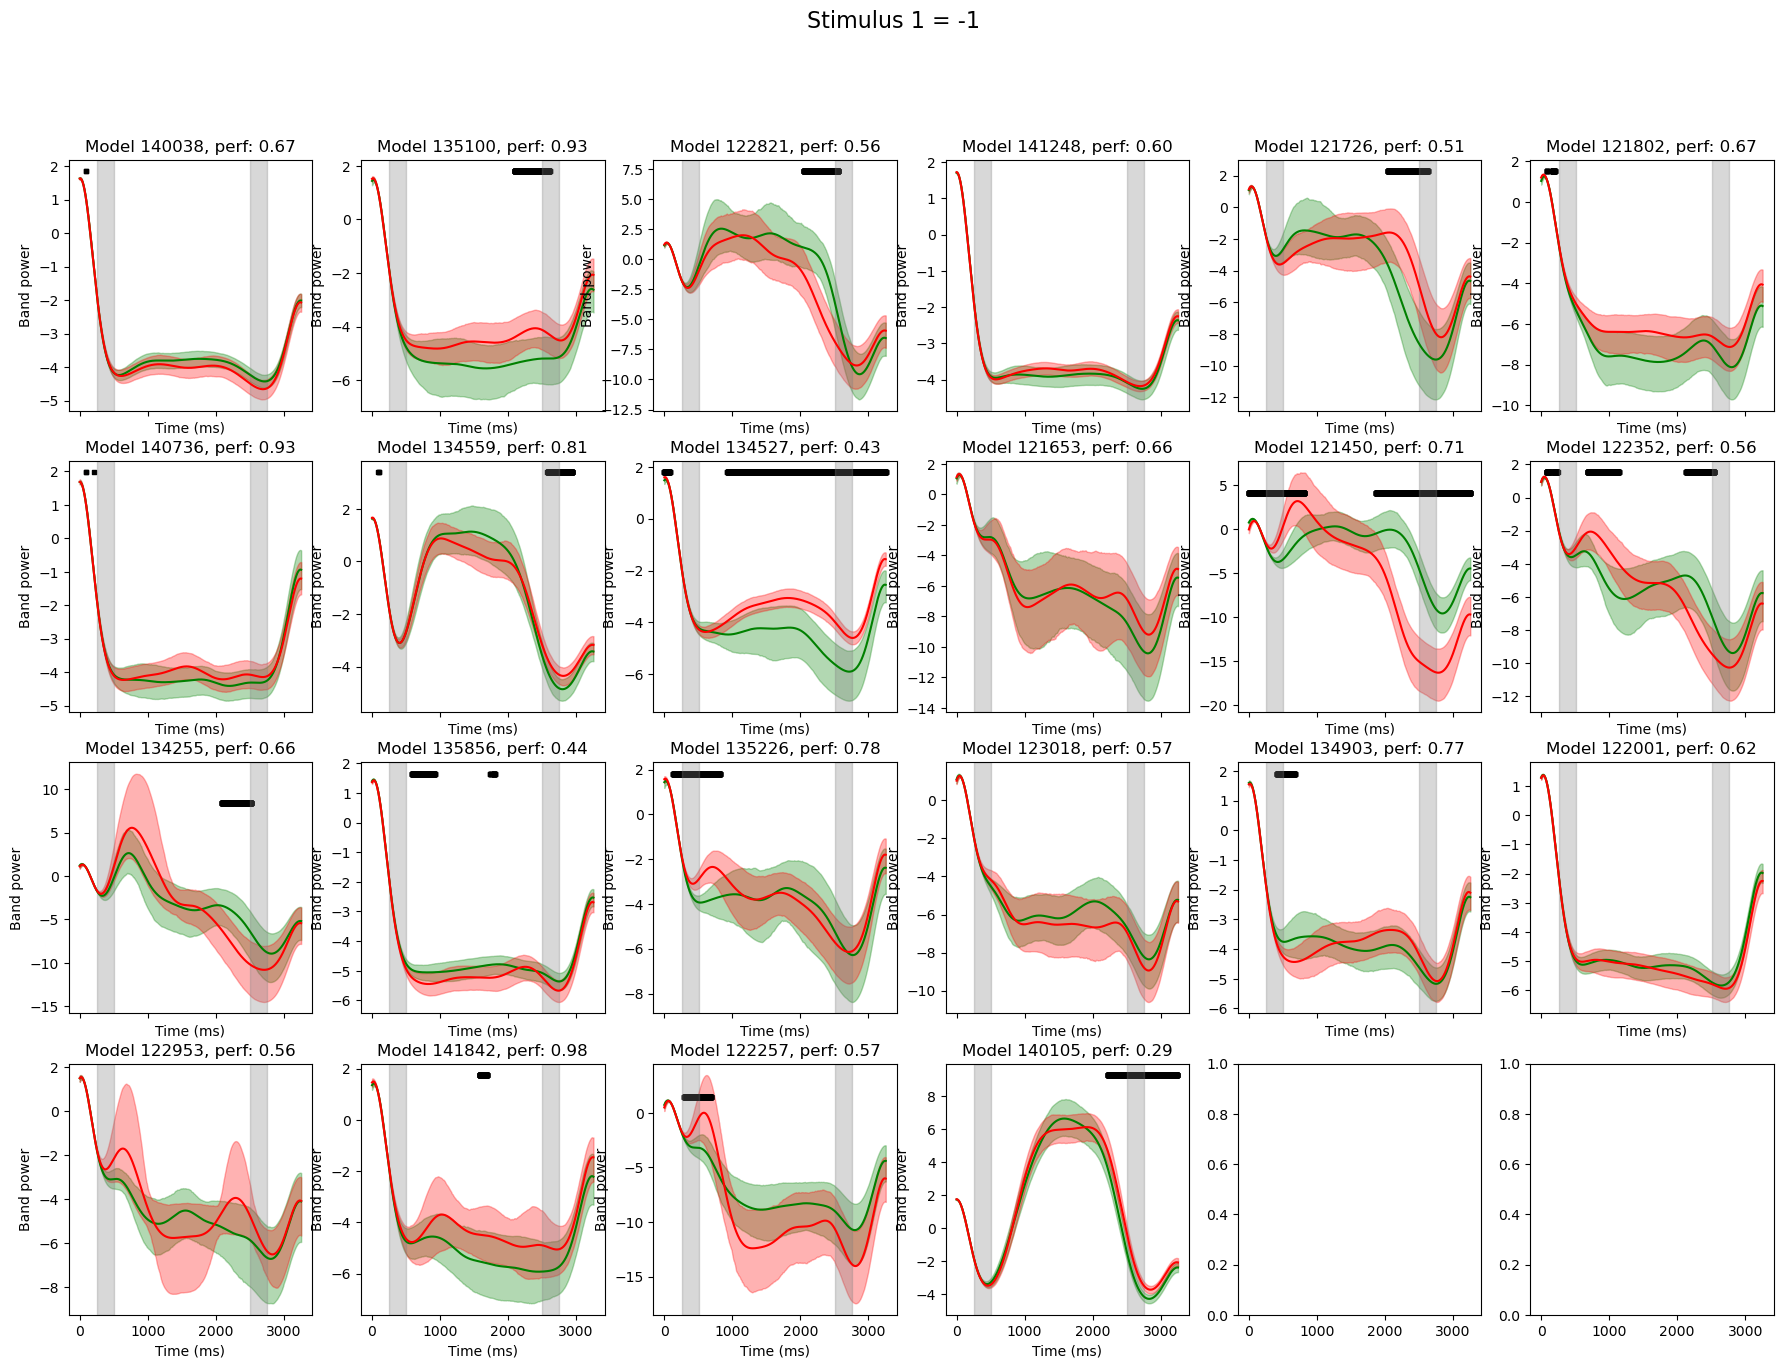

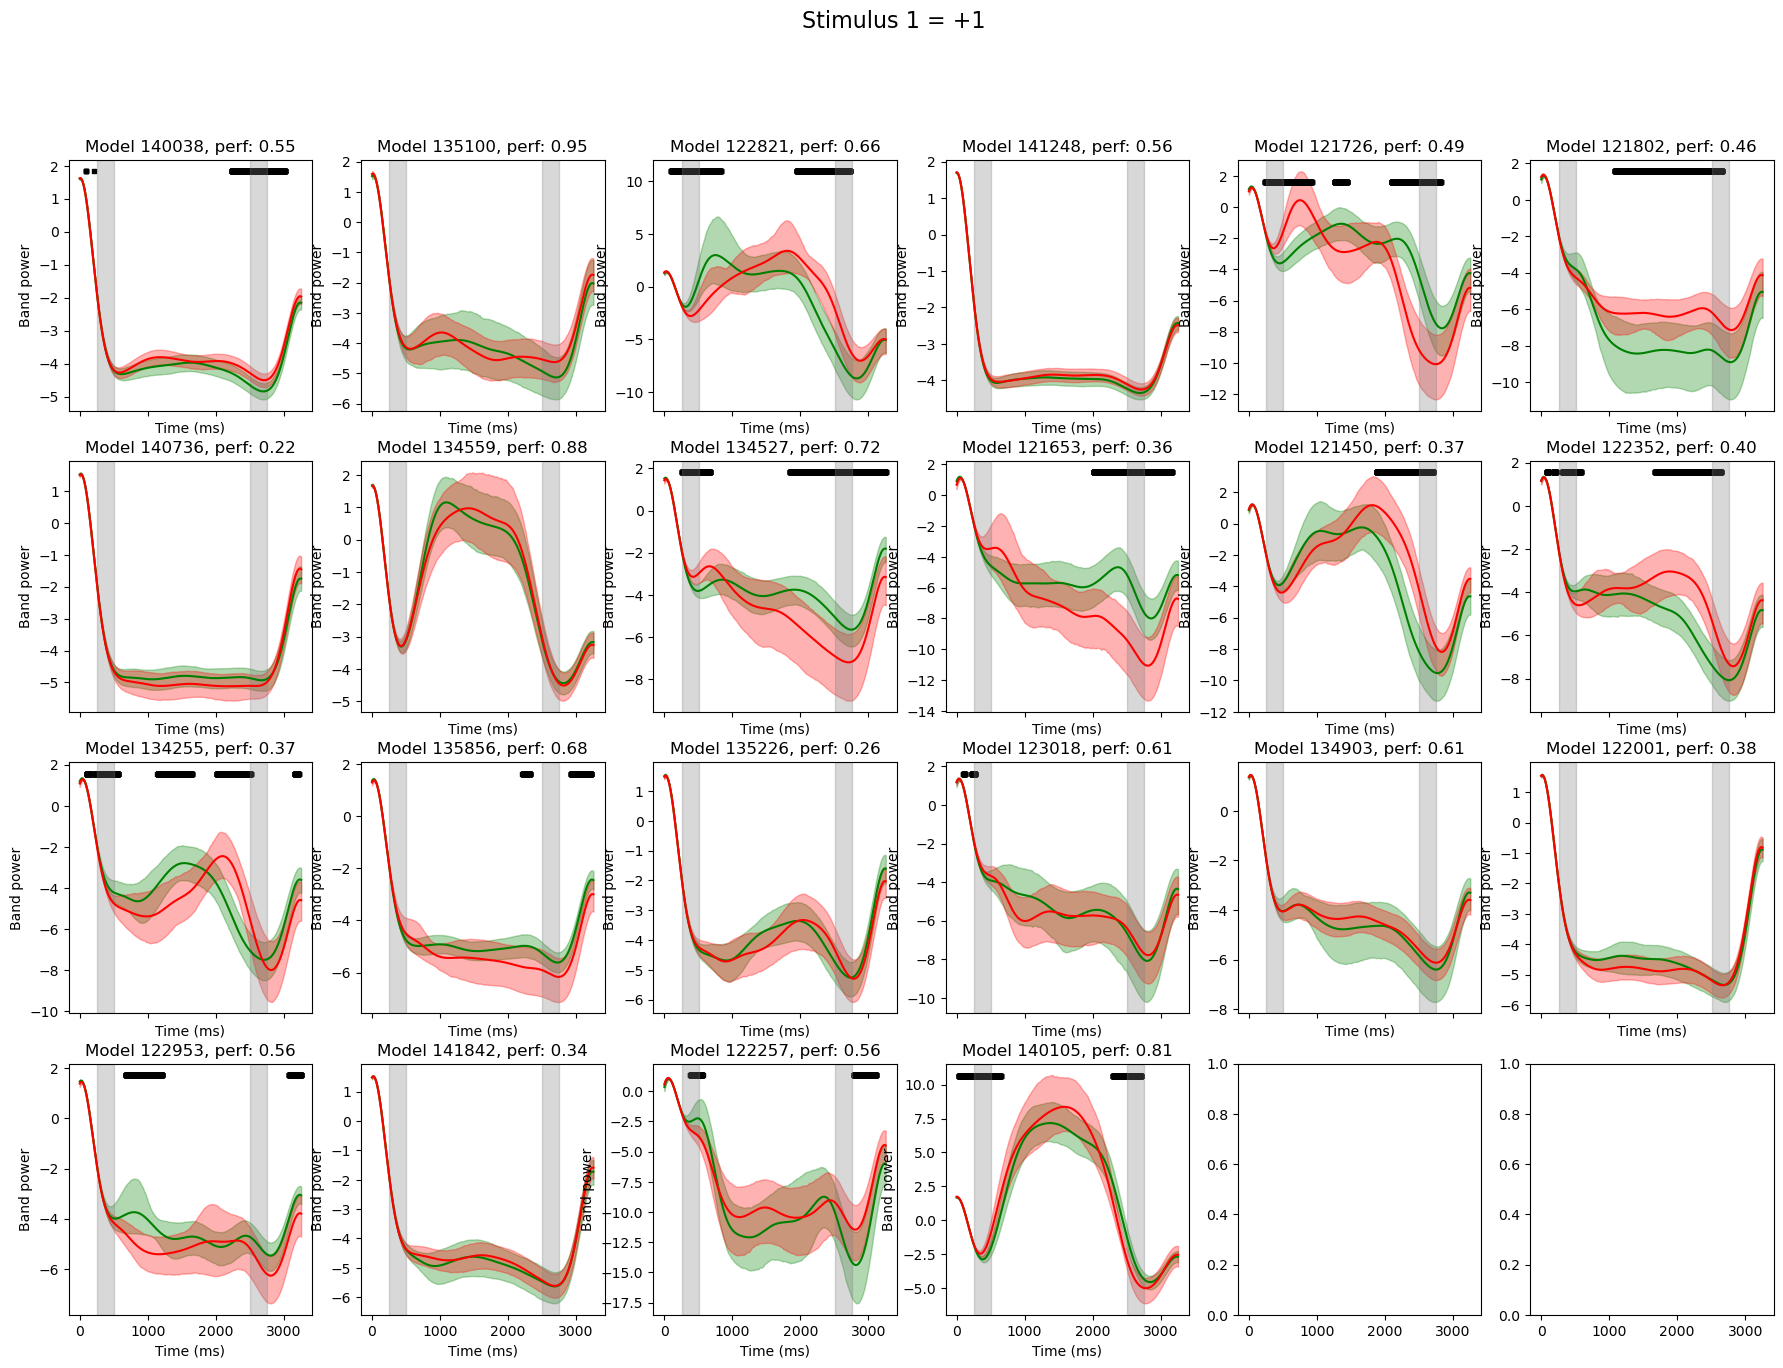

In [7]:
# splitting by the identity of the first stimulus, and then correct vs incorrect

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

stim1 = [-1, 1]

fig1, axs1 = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs1 = axs1.flatten()
fig2, axs2 = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs2 = axs2.flatten()

bandpower_corr_all_neg = []
bandpower_incorr_all_neg = []
bandpower_corr_all_pos = []
bandpower_incorr_all_pos = []

for i_model, model_name in enumerate(theta4_dirs):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    for j, s1 in enumerate(stim1):
        # split by correct vs incorrect trials
        bandpower_corr = bandpower[(trial_perfs==1) & (trial_labels[:,0] == s1),:].squeeze()
        bandpower_incorr = bandpower[(trial_perfs==0) & (trial_labels[:,0] == s1),:].squeeze()
        
        if np.sum((trial_perfs==0) & (trial_labels[:,0] == s1)) < 5: # skip if not enough incorrect trials
            print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum((trial_perfs==0) & (trial_labels[:,0] == s1))}')
            continue

        if j == 0:
            ax = axs1[i_model]
            bandpower_corr_all_neg.append(bandpower_corr)
            bandpower_incorr_all_neg.append(bandpower_incorr)
        else:
            ax = axs2[i_model]
            bandpower_corr_all_pos.append(bandpower_corr)
            bandpower_incorr_all_pos.append(bandpower_incorr)
        
        _= lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                        ax = ax, all_models_dir=all_models_dir, title=f'Model {model_name[-6:]}, perf: {np.sum((trial_perfs==1) & (trial_labels[:,0] == s1)) / np.sum(trial_labels[:,0] == s1):.2f}')

fig1.suptitle('Stimulus 1 = -1', fontsize=16)
fig2.suptitle('Stimulus 1 = +1', fontsize=16)
    

In [8]:
len(bandpower_corr_all_neg), len(bandpower_incorr_all_neg), len(bandpower_corr_all_pos), len(bandpower_incorr_all_pos)

(22, 22, 22, 22)

Text(0.5, 0.98, 'Incorrect Trials')

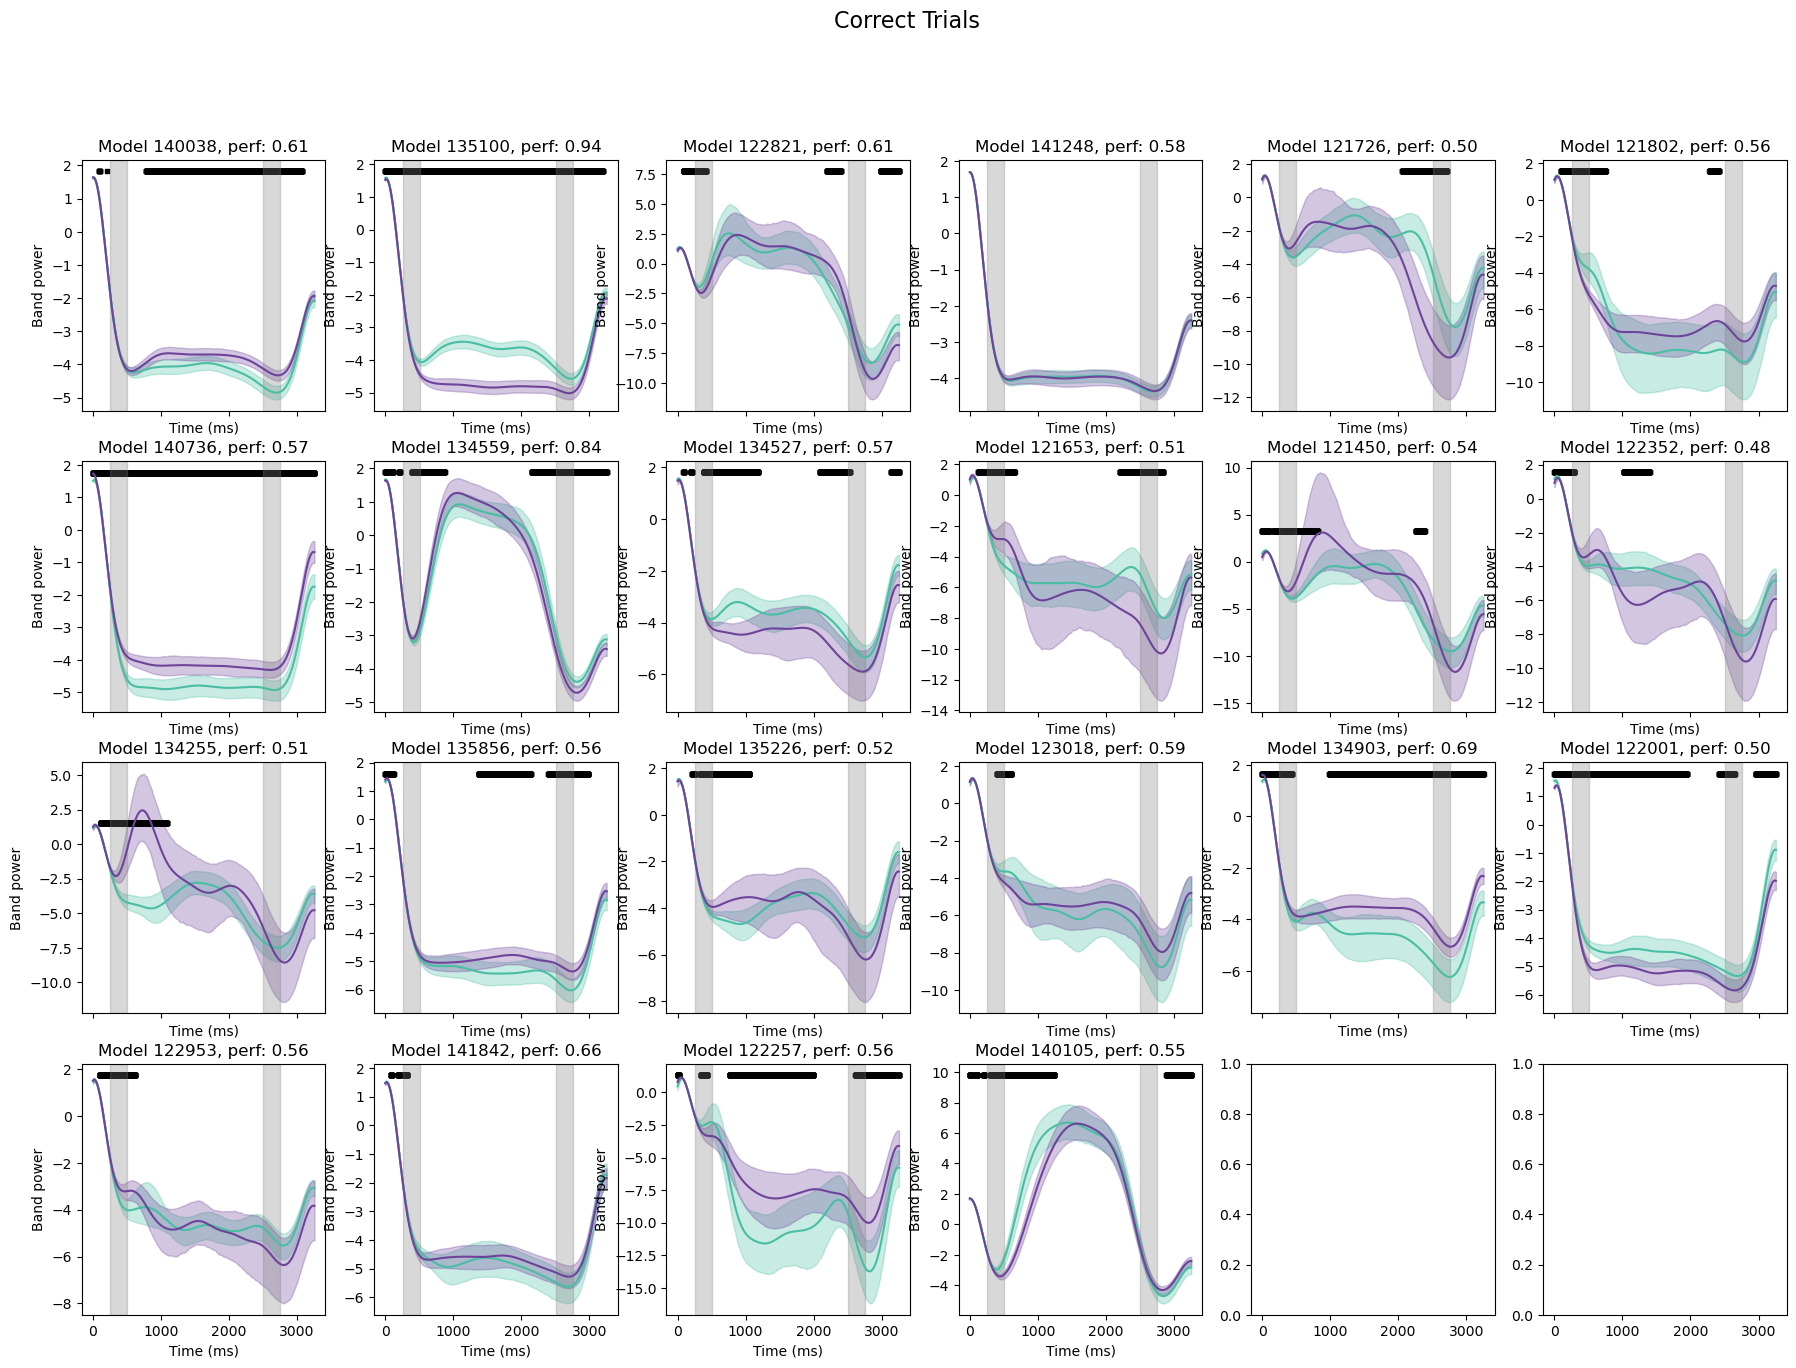

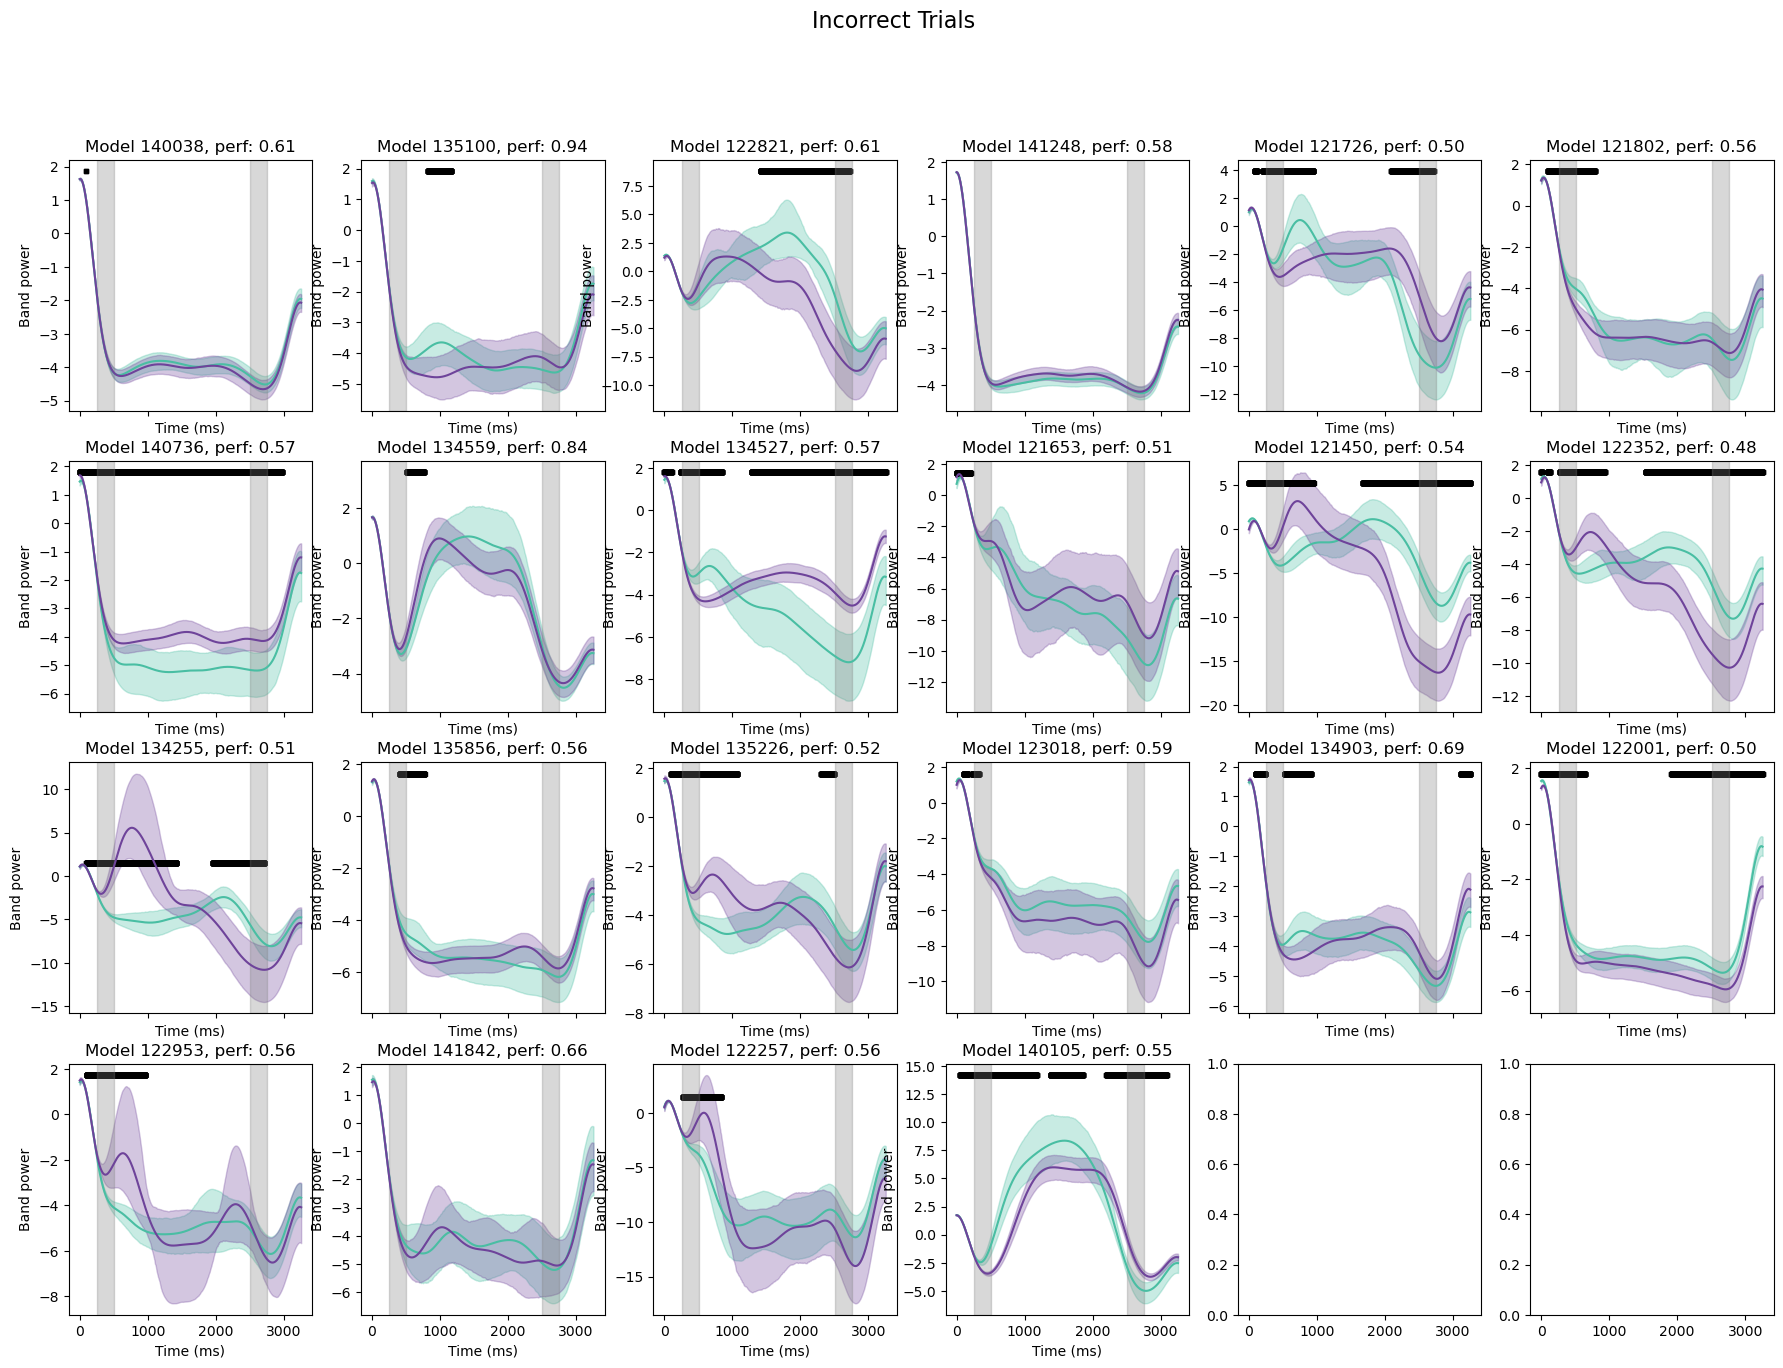

In [10]:
# now compare +1 correct vs -1 correct, and +1 incorrect vs -1 incorrect

importlib.reload(lu)

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

corrs = [1, 0]
colors = ['#49BEA3', '#6E439A']

fig1, axs1 = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs1 = axs1.flatten()
fig2, axs2 = plt.subplots(4, 6, figsize=(22, 15), sharex=True)#, sharey=True)
axs2 = axs2.flatten()

for i_model, model_name in enumerate(theta4_dirs):

    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)


    for j, corr in enumerate(corrs):
        
        if j == 0:
            ax = axs1[i_model]
            bands1 = bandpower_corr_all_pos[i_model]
            bands2 = bandpower_corr_all_neg[i_model]
            label='correct'
        else:
            ax = axs2[i_model]
            bands1 = bandpower_incorr_all_pos[i_model]
            bands2 = bandpower_incorr_all_neg[i_model]
            label='incorrect'
        
        _= lu.plot_bandpower_bootstrap(model_name, bands1, bands2, condn_phrase, condn_num, 
                                        ax = ax, all_models_dir=all_models_dir, colors=colors, title=f'Model {model_name[-6:]}, perf: {np.mean(trial_perfs):.2f}')

fig1.suptitle('Correct Trials', fontsize=16)
fig2.suptitle('Incorrect Trials', fontsize=16)
    

#### try doing LFP as exc or inh only -- didn't run

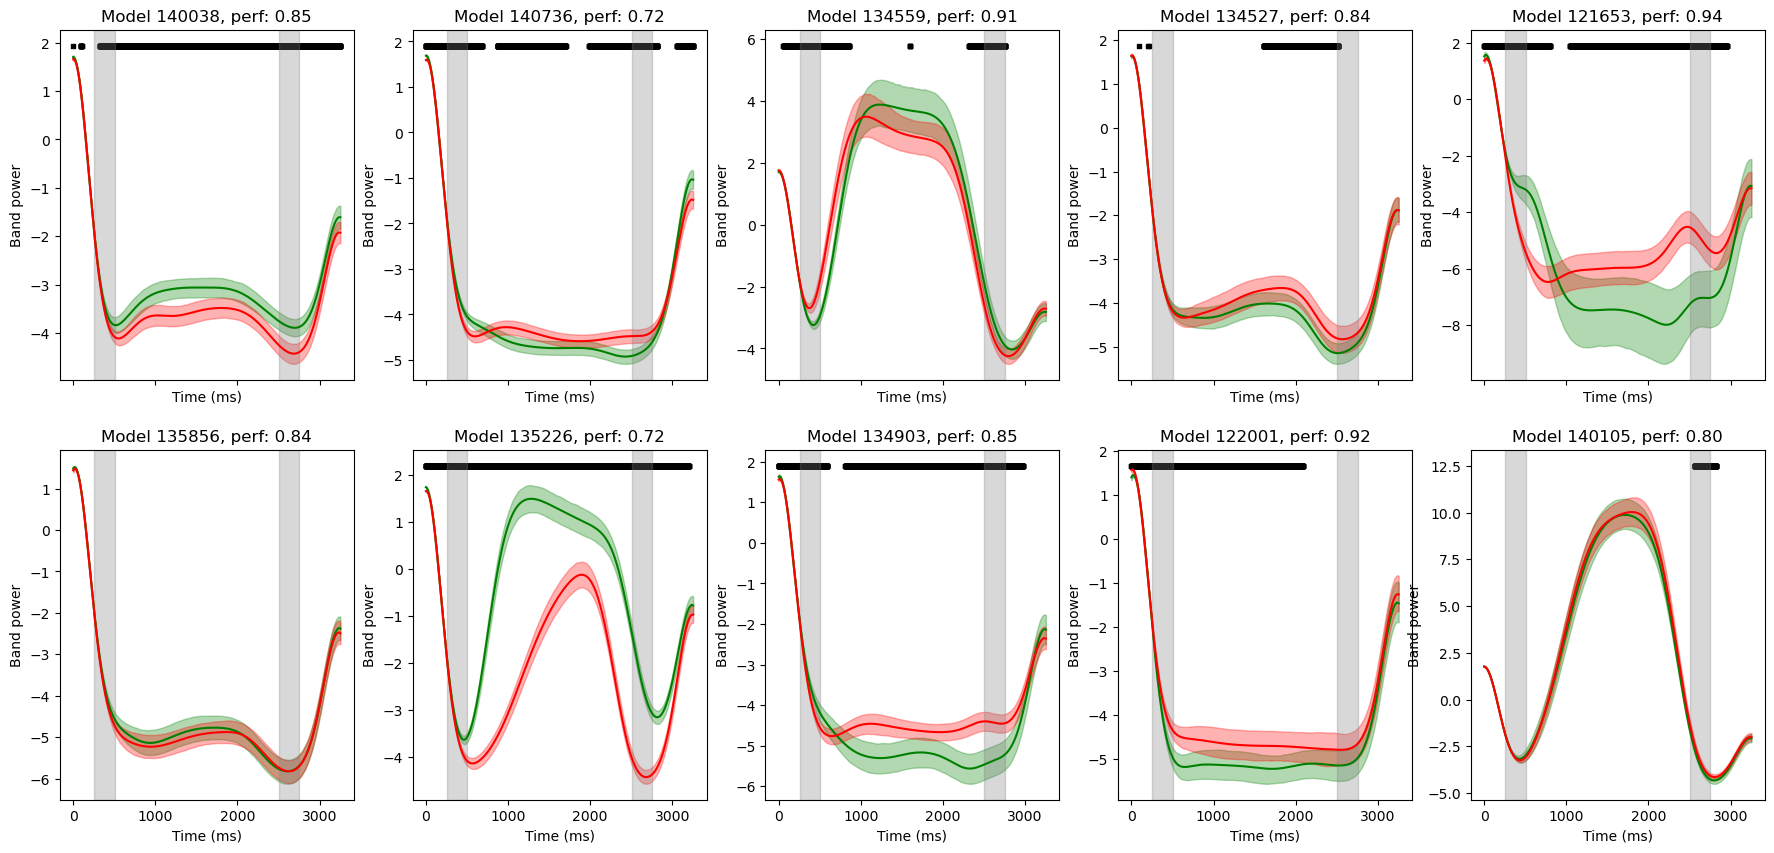

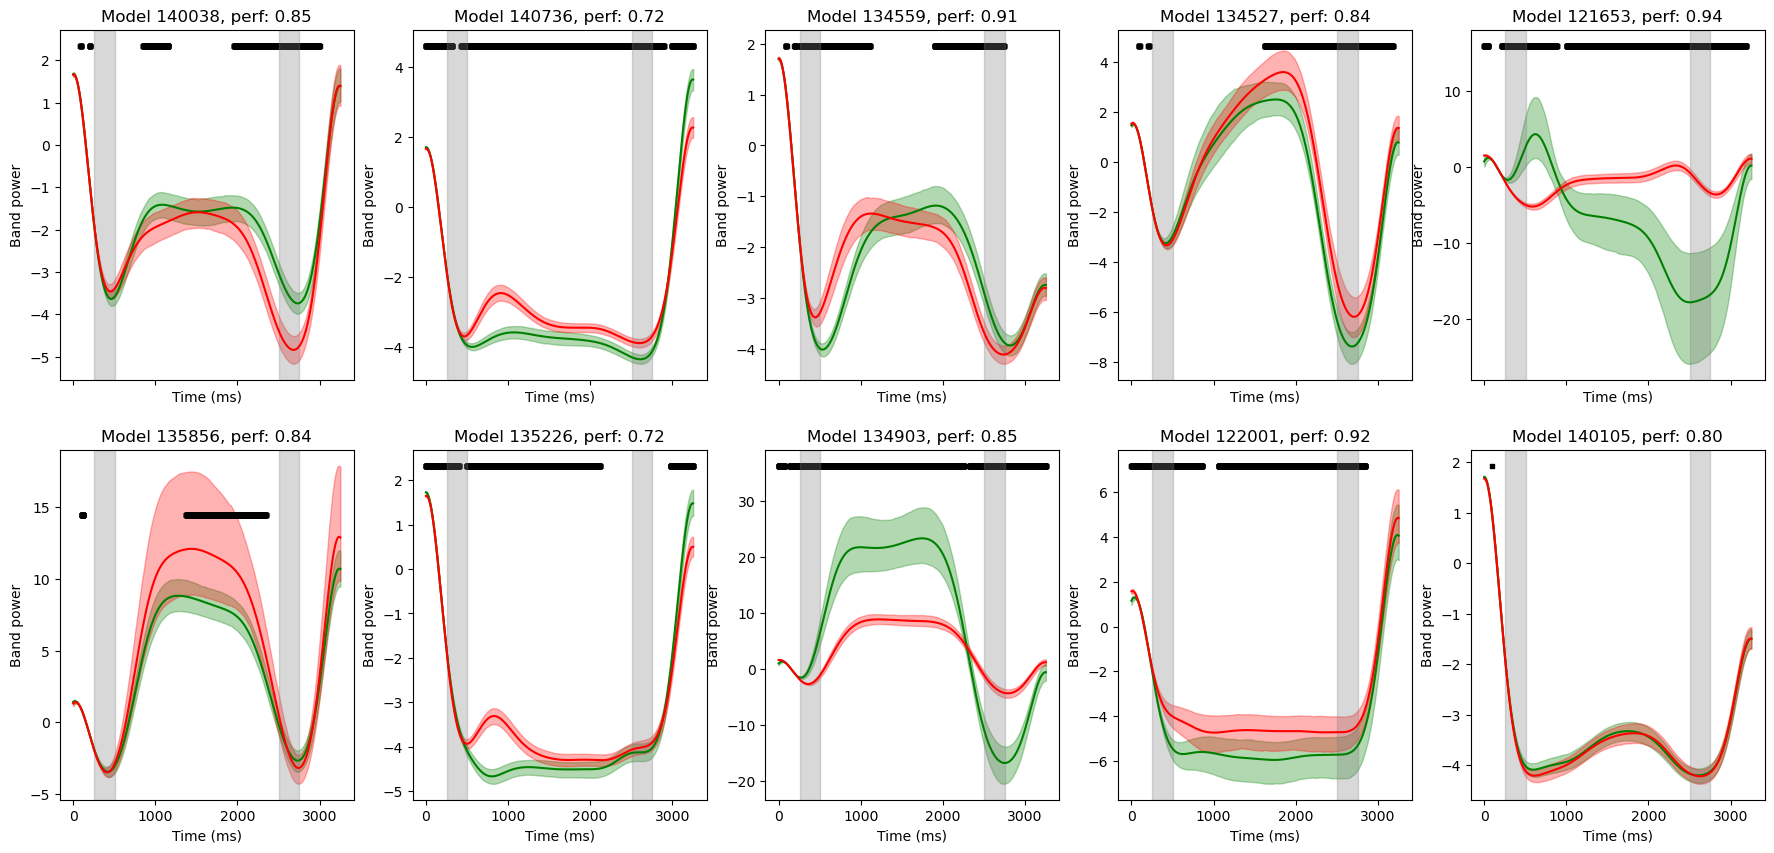

In [42]:
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

fig1, axs1 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs1 = axs1.flatten()
fig2, axs2 = plt.subplots(2, 5, figsize=(22, 10), sharex=True)#, sharey=True)
axs2 = axs2.flatten()

for i_model, model_name in enumerate(theta4_models_select):
    # LFP data
    lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=False, load_rates=False,
                                                  all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    # timing data
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, 
                   model_name=model_name, all_models_dir=all_models_dir)
    
    # sampling rates
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    
    # calculate power and bandpower (4Hz, baselining)
    power_exc, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data[:,exc_ind,:], axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower_exc, _ = lu.calc_band_power(power_exc, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])
    power_inh, freqs, _ = lu.compute_lfp_power(np.mean(lfp_data[:,inh_ind,:], axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower_inh, _ = lu.calc_band_power(power_inh, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    for j, celltype in enumerate(['Excitatory', 'Inhibitory']):
        if celltype == 'Excitatory':
            bandpower = bandpower_exc
        else:
            bandpower = bandpower_inh

        if np.sum(trial_perfs==0) < 5: # skip if not enough incorrect trials
            print(f'Skipping model {model_name} due to insufficient incorrect trials, n={np.sum(trial_perfs==0)}')
            continue
        
        if j == 0:
            ax = axs1[i_model]
        else:
            ax = axs2[i_model]
        ax.set_title(f'Model {model_name[-6:]}, perf: {np.mean(trial_perfs):.2f}, {celltype[:3]}')
        
        # split by correct vs incorrect trials
        bandpower_corr = bandpower[trial_perfs==1,:].squeeze()
        bandpower_incorr = bandpower[trial_perfs==0,:].squeeze()
        
        # plot with bootstrap CIs
        _ = lu.plot_bandpower_bootstrap(model_name, bandpower_corr, bandpower_incorr, condn_phrase, condn_num, 
                                    ax = ax, all_models_dir=all_models_dir)
        
        
 